# Numerical solver for the discrete space and structured model

### Setup

Import the model and paramater class from the file model_solver

In [9]:
%load_ext autoreload
%autoreload 2

# Standard Imports
import numpy as np
import matplotlib.pyplot as plt

# Your Custom Import
from model_solver import Params, MacrophageModel

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Parameters and execution

In [10]:
# Define your parameters
p = Params(
    M=50, N=100, kplus=1, kminus=1, beta=2, D_min=0.1, gamma=0.2,
    sigma_b=0.004, sigma_max=0.4, V_tot=100000, delta_v=0.005, theta=1, debug=True
)

t_final = 20.0

In [11]:
# Instantiate the model
model = MacrophageModel(p)

# Setup Time
t_span = (0.0, t_final)
t_eval = np.linspace(t_span[0], t_span[1], 500)

# Run the solver!
print("Starting solver...")
U, sol = model.solve(t_span, t_eval)
print(f"Solver finished successfully: {sol.success}")

# Check if the results are obey the physics
model.validate_results(U)

# Extract all data
results = model.compute_diagnostics(U)

Starting solver...
Solver finished successfully: True
--- Running Post-Simulation Sanity Checks ---
[✓] All physical constraints respected!
---------------------------------------------


### Plotting and analysis

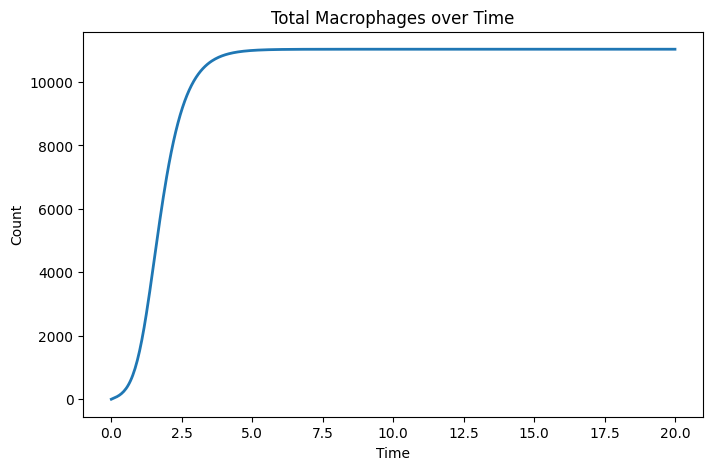

In [13]:
# Plot total macrophages over time
plt.figure(figsize=(8, 5))
plt.plot(sol.t, results["totals"]["macrophage_number"], linewidth=2)
plt.title("Total Macrophages over Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.grid(False)
plt.show()